# Assignment 2 – Zero-Shot Image Classification with Transformers

In this assignment, you will apply a pre-trained vision–language transformer (e.g. CLIP) to perform **zero-shot** classification on the Fashion-MNIST dataset—classifying each image without any task-specific training. You will build on the concepts from Assignment 1 by comparing this “off-the-shelf” approach to the CNN you previously trained.

You will:
1. **Load** the Fashion-MNIST images using PyTorch instead of Keras.
2. **Run a zero-shot baseline** with simple text prompts to set a performance reference.
3. **Engineer improved prompts** and measure the resulting accuracy gains.
4. **Visualise image embeddings** with UMAP to inspect class separability.
5. **Conduct one mini-experiment** of your choice.
6. **Summarise findings** and reflect on strengths and weaknesses of zero-shot transformers versus a trained CNN.

# 1. Loading the Fashion-MNIST Dataset

As in assignment 1, we'll load the Fashion-MNIST dataset, but this time using `torchvision.datasets` to ensure compatibility with the `transformers` library. We will also load our model and processor from the `transformers` library.

The transformers library allows us to use pre-trained models like CLIP, which can perform zero-shot classification by leveraging the text prompts we provide. There are two key objects we will use: the `CLIPModel` for the model itself and the `CLIPProcessor` for preparing our images and text prompts.

Since we are not actually training a model in this assignment, we will set the CLIP model to evaluation mode. If the model is designed to utilize features like dropout or batch normalization, setting it to evaluation mode ensures that these features behave correctly during inference (prediction). Setting the model to evaluaton mode also tells PyTorch that we don't have to compute gradients, which can save memory and speed up inference.

In order to speed up processing, we will also move the model to an "accelerator" if available. This is typically a GPU, but modern MacBooks also have an "Apple Silicon" accelerator that can be used for inference, called MPS (Metal Performance Shaders). If you are using a MacBook with Apple Silicon, you can use the MPS device for faster processing.

In [3]:
# Uncomment and run if required
!pip install transformers torchvision torch accelerate

In [4]:
from transformers import CLIPModel, CLIPProcessor
import torch

clip_model_name = "openai/clip-vit-base-patch32"
clip_model     = CLIPModel.from_pretrained(clip_model_name)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name, use_fast=False)

# Set model to evaluation mode, as we are not training it
clip_model.eval()

# Check for accelerators
device = "cpu" # Default to CPU
if torch.cuda.is_available():
    device = "cuda" # Use GPU if available
elif torch.backends.mps.is_available():
    device = "mps"

clip_model.to(device)

print(f"Using device: {device}")

Using device: mps


Now we are ready to load the testing set from Fashion-MNIST. We will use the `torchvision.datasets.FashionMNIST` class to load the dataset. We do not need to apply any transformations to the images, as the `CLIPProcessor` ensures any input images are in the format that the model is trained on.

You should:

- [ ] Use the `torchvision.datasets.FashionMNIST` class to load the *test* split of the dataset. Documentation is available [here](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html).
- [ ] Create a PyTorch `DataLoader` to iterate over the dataset in batches. Use a batch size of 16 and set `shuffle=True` to randomise the order of the images. You will also need to supply the provided `collate_clip` function to the `DataLoader collate_fn` argument to ensure the images are processed correctly. Documentation for `DataLoader` is available [here](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

In [5]:
from torchvision import datasets
from torch.utils.data import DataLoader

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

def collate_clip(batch):
    imgs, labels = zip(*batch) # Unzip the batch into images and labels
    proc = clip_processor(images=list(imgs),
                        return_tensors="pt",
                        padding=True) # Process images with CLIPProcessor
    # Send pixel_values to GPU/CPU now; labels stay on CPU for metrics
    return proc["pixel_values"].to(device), torch.tensor(labels)

test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True, collate_fn=collate_clip)

If your code is correct, the following cell should show the first batch of images from the Fashion-MNIST dataset:

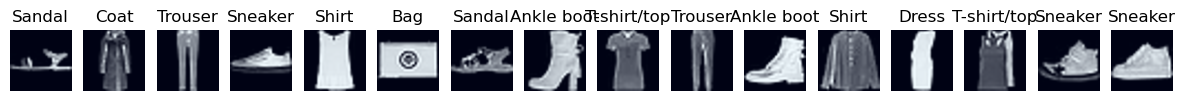

In [6]:
import matplotlib.pyplot as plt

# Display the first batch of images from `test_loader`

def show_batch(loader):
    images, labels = next(iter(loader))
    images = images.cpu()  # Move images to CPU for plotting
    # Renormalize to [0, 1] for visualization
    images = (images - images.min()) / (images.max() - images.min())
    _, axes = plt.subplots(1, len(images), figsize=(15, 5))
    for ax, img, label in zip(axes, images, labels):
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(CLASS_NAMES[label.item()])
        ax.axis('off')
    plt.show()

show_batch(test_loader)

We’re now ready to run our zero-shot classification baseline!

# Brief Introduction to Zero-Shot Classification

In Assignment 1, we followed the typical machine-learning pipeline: we trained a CNN on the Fashion-MNIST dataset, using labelled examples to update the model’s weights. While effective, that approach requires a curated, task-specific training set—a luxury you don’t always have in practice.

Zero-shot classification flips the script.  A large vision–language model (VLM) such as **CLIP** is first pre-trained on hundreds of millions of image–text pairs scraped from the web.  Because it learns *joint* visual–textual embeddings, the model can later solve new tasks simply by “measuring” how similar an image is to a **text prompt** that describes each candidate class—without seeing a single task-labelled example.

**How it works**  
1. Feed an image through CLIP’s vision encoder → **image feature**.  
2. Feed a textual prompt (e.g. “a photo of a sandal”) through CLIP’s text encoder → **text feature**.  
3. Compute cosine similarity between the image feature and every class’s text feature.  
4. Pick the class whose prompt is most similar.

For our first attempt, we’ll use the bare class names as prompts, e.g.:

- "T-shirt/top"
- "Trouser"

### You should:

- [ ] Build embeddings: use the `get_text_embeddings` helper function to create text embeddings for the class names.
- [ ] Run inference: use the `get_image_embeddings` helper function to create image embeddings.
- [ ] Compute cosine similarity: complete and use the `get_cosine_similarity` helper function to compute the cosine similarity between the image and text embeddings.
- [ ] Make predictions: use the `get_predictions` helper function to get the predicted class for each image in the batch.

Note that for normalized vectors like the ones we are using, cosine similarity is equivalent to the dot product. This means we can use the handy formula `cosine_similarity = vector_a @ vector_b.T` to compute the similarity between the image and text embeddings.

In [7]:
def get_text_embeddings(class_names: list[str]) -> torch.Tensor:
    """    Get text embeddings for the given class names using CLIP.
    Args:
        class_names (list[str]): List of class names to encode.
    Returns:
        torch.Tensor: Normalized text embeddings for the class names.
    """
    tokenized = clip_processor(text=class_names,
                               padding=True,
                               return_tensors="pt").to(device)
    
    with torch.no_grad():
        text_embeddings = clip_model.get_text_features(**tokenized)

    text_feats = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

    return text_feats

def get_image_embeddings(images: torch.Tensor) -> torch.Tensor:
    """    Get image embeddings for the given images using CLIP.
    Args:
        images (torch.Tensor): Batch of images to encode.
    Returns:
        torch.Tensor: Normalized image embeddings for the images.
    """
    with torch.no_grad():
        image_embeddings = clip_model.get_image_features(pixel_values=images)

    image_feats = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)

    return image_feats

In [8]:
import numpy as np

def get_cosine_similarity(image_feats: torch.Tensor, text_feats: torch.Tensor) -> np.ndarray:
    """
    Compute cosine similarity between image features and text features.
    Args:
        image_feats (torch.Tensor): Image features of shape (N, D).
        text_feats (torch.Tensor): Text features of shape (M, D).
    Returns:
        numpy.ndarray: Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    """
    image_feats = image_feats.cpu()  # Ensure image features are on CPU
    text_feats = text_feats.cpu()    # Ensure text features are on CPU

    # Compute cosine similarity, which is the dot product of normalized vectors
    return (image_feats @ text_feats.T).numpy()

def get_predictions(similarity: np.ndarray) -> np.ndarray:
    """
    Get predictions based on cosine similarity scores.
    Args:
        similarity (numpy.ndarray): Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    Returns:
        numpy.ndarray: Predicted class indices for each image, shape (N,).
    """
    # Get the index of the maximum similarity for each image
    return np.argmax(similarity, axis=1)

With these functions complete, you are ready to run the zero-shot classification baseline. Complete the code to follow these steps:

- [ ] Build text embeddings for the class names using the `get_text_embeddings` function (this only needs to be done once).
- [ ] For each batch of images:
    - [ ] Get image embeddings using the `get_image_embeddings` function.
    - [ ] Compute cosine similarity between the image and text embeddings using the `get_cosine_similarity` function.
    - [ ] Save the predictions so that we can build a confusion matrix later.
- [ ] Report the accuracy of the predictions and the confusion matrix using the `accuracy_score` and `confusion_matrix` functions from `sklearn.metrics`.

Zero-shot classification accuracy: 0.6240


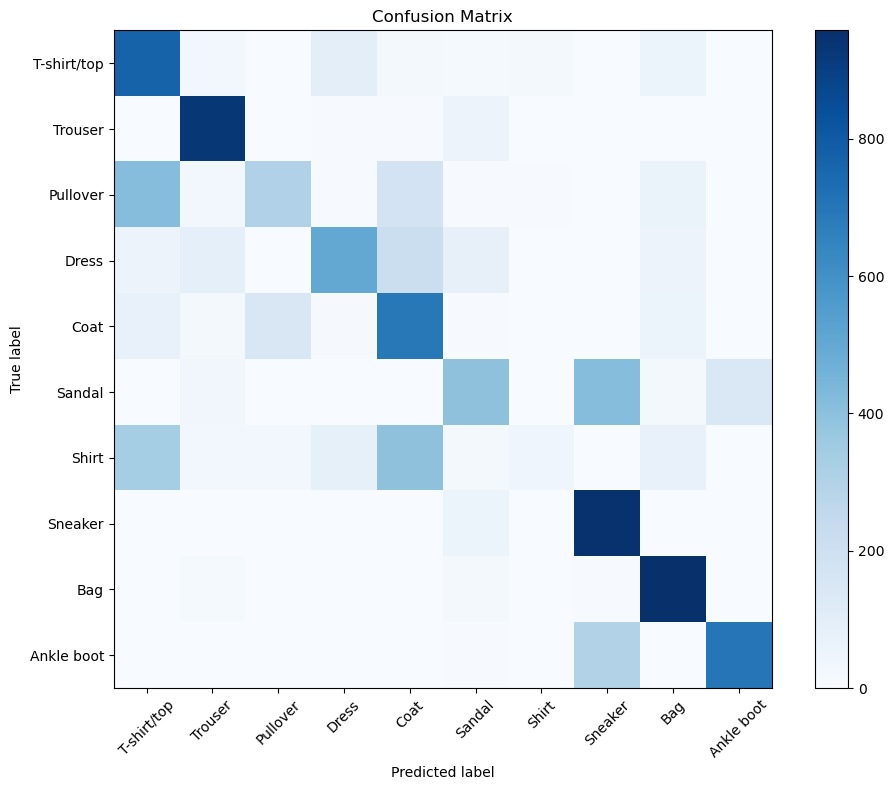

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_true, y_pred = [], []

# Build text embeddings for the class names (only needs to be done once)
text_embeddings = get_text_embeddings(CLASS_NAMES)

for pixel_values, labels in test_loader:
    # Get image embeddings
    image_embeddings = get_image_embeddings(pixel_values)
    
    # Compute cosine similarity between image and text embeddings
    similarity = get_cosine_similarity(image_embeddings, text_embeddings)
    
    # Get predictions
    predictions = get_predictions(similarity)
    
    # Save predictions and true labels for confusion matrix
    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

# Report the accuracy of the predictions
accuracy = accuracy_score(y_true, y_pred)
print(f"Zero-shot classification accuracy: {accuracy:.4f}")

# Report the confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_true, y_pred, CLASS_NAMES)

Reflection: Consider the results. How does the performance of this zero-shot baseline compare to the CNN you trained in Assignment 1? What are the strengths and weaknesses of this approach?

## Improving Zero-Shot Classification with Prompt Engineering

In the previous section, we directly used the class names as text prompts for zero-shot classification. However, we can often improve performance by crafting more descriptive prompts that better capture the visual characteristics of each class. For example, instead of just "T-shirt/top", we could use "a photo of a T-shirt" or "a photo of a top". This additional context can help the model make more accurate predictions.

In this section, we will experiment with more detailed prompts for each class to see if we can improve the zero-shot classification performance. You should:

- [ ] Create a list of improved prompts for each class. For example, instead of just "T-shirt/top", you could use "a photo of a T-shirt" or "a photo of a top".
- [ ] Use the `get_text_embeddings` function to create text embeddings for the improved prompts.
- [ ] Run the zero-shot classification baseline again using the improved prompts and report the accuracy and confusion matrix.

Note: Take advantage of the confusion matrix above. If two classes are often confused, consider how you might improve the prompts to help the model distinguish them better.

The aim for this section is for you to improve the performance of the model. However, if you find that the performance does not improve significantly, you can still reflect on the process and consider how you might further refine the prompts with more effort.

Original class names:
0: T-shirt/top
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot

Improved prompts:
0: a photo of a t-shirt or top clothing item
1: a photo of long pants or trousers
2: a photo of a pullover sweater or jumper
3: a photo of a dress or gown
4: a photo of a coat or jacket outerwear
5: a photo of open-toe sandals or flip-flops
6: a photo of a collared shirt or blouse
7: a photo of athletic sneakers or tennis shoes
8: a photo of a handbag, purse, or backpack
9: a photo of ankle boots or short boots

Running zero-shot classification with improved prompts...

Improved prompts accuracy: 0.6708
Baseline accuracy: 0.6240
Improvement: 0.0468

Confusion Matrix for Improved Prompts:


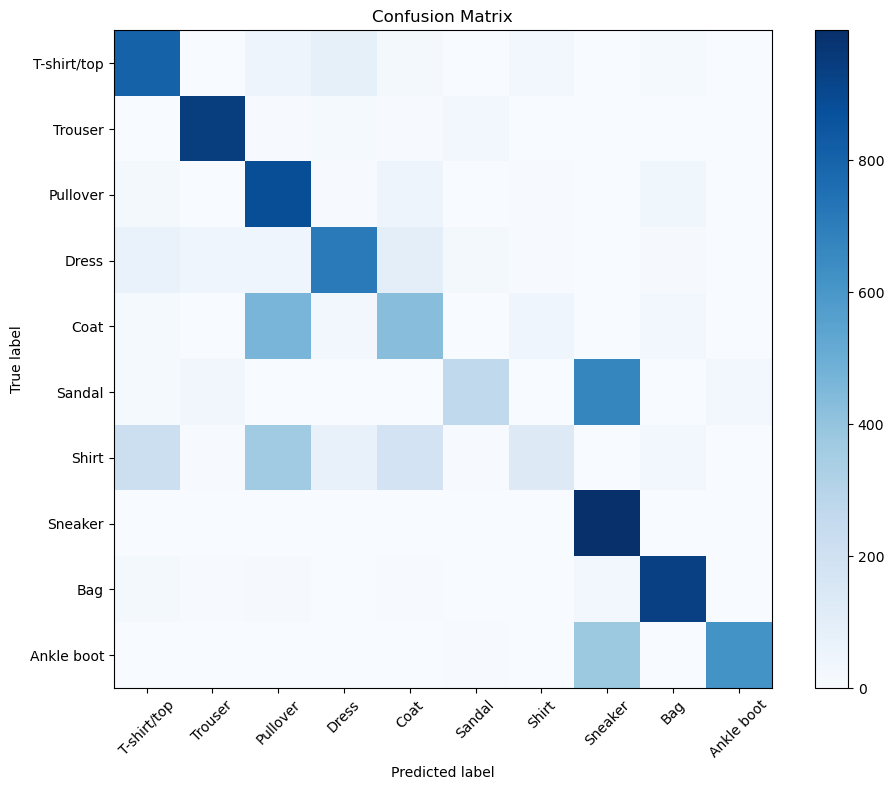

In [10]:
# Create improved descriptive prompts for each class
IMPROVED_PROMPTS = [
    "a photo of a t-shirt or top clothing item",     # T-shirt/top
    "a photo of long pants or trousers",             # Trouser
    "a photo of a pullover sweater or jumper",       # Pullover
    "a photo of a dress or gown",                    # Dress
    "a photo of a coat or jacket outerwear",         # Coat
    "a photo of open-toe sandals or flip-flops",    # Sandal
    "a photo of a collared shirt or blouse",        # Shirt
    "a photo of athletic sneakers or tennis shoes", # Sneaker
    "a photo of a handbag, purse, or backpack",     # Bag
    "a photo of ankle boots or short boots"         # Ankle boot
]

print("Original class names:")
for i, name in enumerate(CLASS_NAMES):
    print(f"{i}: {name}")

print("\nImproved prompts:")
for i, prompt in enumerate(IMPROVED_PROMPTS):
    print(f"{i}: {prompt}")

# Reset prediction lists for improved prompts experiment
y_true_improved, y_pred_improved = [], []

# Build text embeddings for the improved prompts
text_embeddings_improved = get_text_embeddings(IMPROVED_PROMPTS)

print(f"\nRunning zero-shot classification with improved prompts...")

for pixel_values, labels in test_loader:
    # Get image embeddings
    image_embeddings = get_image_embeddings(pixel_values)
    
    # Compute cosine similarity between image and text embeddings
    similarity = get_cosine_similarity(image_embeddings, text_embeddings_improved)
    
    # Get predictions
    predictions = get_predictions(similarity)
    
    # Save predictions and true labels for confusion matrix
    y_true_improved.extend(labels.numpy())
    y_pred_improved.extend(predictions)

# Report the accuracy of the improved prompts
accuracy_improved = accuracy_score(y_true_improved, y_pred_improved)
print(f"\nImproved prompts accuracy: {accuracy_improved:.4f}")
print(f"Baseline accuracy: {accuracy:.4f}")
print(f"Improvement: {accuracy_improved - accuracy:.4f}")

# Plot confusion matrix for improved prompts
print("\nConfusion Matrix for Improved Prompts:")
plot_confusion_matrix(y_true_improved, y_pred_improved, CLASS_NAMES)

Reflection: How did your detailed prompts affect the zero-shot classification performance? Did you see a significant improvement compared to the baseline? What insights did you gain about the model's understanding of the classes? Do you think that with more effort you could further improve the performance? If so, how?

## Visualizing Image Embeddings with UMAP

To better understand how the model perceives the different classes, we can visualize the image embeddings using UMAP (Uniform Manifold Approximation and Projection). UMAP is a dimensionality reduction technique that helps us see how similar or dissimilar the embeddings are in a lower-dimensional space.

By visualizing the embeddings, we can gain insights into how well the model can distinguish certain images, even without considering the text prompts. This can help us identify clusters of similar images and see if there are any overlaps between classes.

You should:

- [ ] Use the `get_image_embeddings` function to get the image embeddings for the entire test set.
- [ ] Use UMAP to reduce the dimensionality of the image embeddings to 2D.
- [ ] Plot the 2D embeddings, coloring each point by its true class label.

You may need to install the `umap-learn` library if you haven't already. You can do this by running `pip install umap-learn`.

In [11]:
# Uncomment the following line to install UMAP if you haven't already
!pip install umap-learn

Collected embeddings shape: (10000, 512)
Number of labels: 10000
Fitting UMAP to reduce dimensionality to 2D...


/opt/miniconda3/envs/ml_deeplearning/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP embeddings shape: (10000, 2)


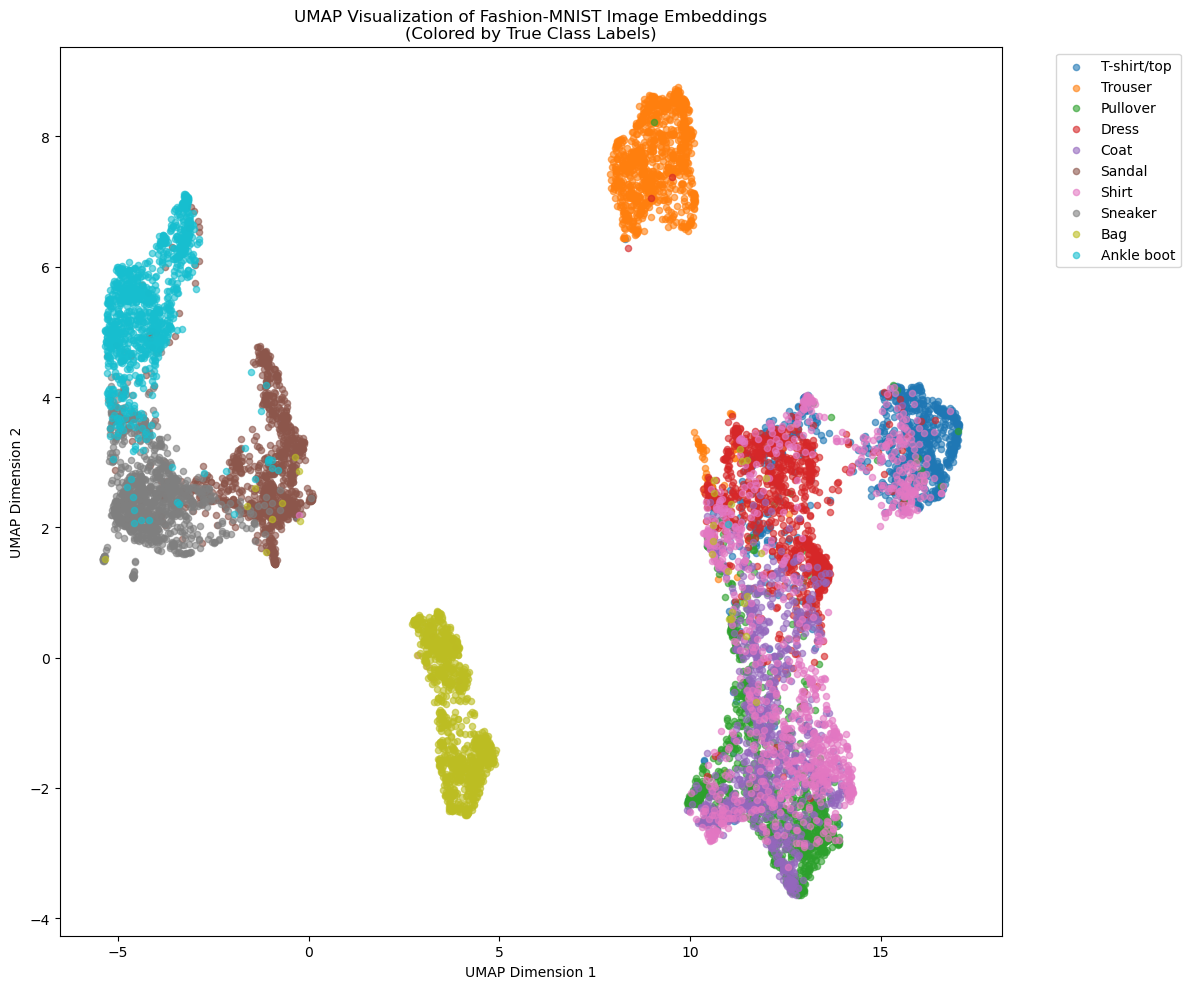

In [12]:
from umap import UMAP

# ------------------------------------------------------------
# 1. Collect image embeddings
# ------------------------------------------------------------
all_img_emb = []
all_labels  = []

print("Collecting image embeddings for UMAP visualization...")
for pixel_values, labels in test_loader:
    # Get image embeddings for this batch
    image_embeddings = get_image_embeddings(pixel_values)
    
    # Store embeddings and labels
    all_img_emb.append(image_embeddings.cpu().numpy())
    all_labels.extend(labels.numpy())

# Concatenate all embeddings into a single array
all_img_emb = np.concatenate(all_img_emb, axis=0)
all_labels = np.array(all_labels)

print(f"Collected embeddings shape: {all_img_emb.shape}")
print(f"Number of labels: {len(all_labels)}")

# ------------------------------------------------------------
# 2. Fit UMAP
# ------------------------------------------------------------
print("Fitting UMAP to reduce dimensionality to 2D...")
umap_reducer = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
umap_embeddings = umap_reducer.fit_transform(all_img_emb)

print(f"UMAP embeddings shape: {umap_embeddings.shape}")

# ------------------------------------------------------------
# 3. Plot coloured by ground-truth label
# ------------------------------------------------------------
plt.figure(figsize=(12, 10))

# Create a color map for the classes
colors = plt.cm.tab10(np.linspace(0, 1, len(CLASS_NAMES)))

# Plot each class with a different color
for i, class_name in enumerate(CLASS_NAMES):
    mask = all_labels == i
    plt.scatter(
        umap_embeddings[mask, 0], 
        umap_embeddings[mask, 1], 
        c=[colors[i]], 
        label=class_name, 
        alpha=0.6, 
        s=20
    )

plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.title('UMAP Visualization of Fashion-MNIST Image Embeddings\n(Colored by True Class Labels)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The UMAP embeddings allow us to see how separable or non-separable different classes are with our specific model. If two specific images are very similar, then they will be placed near each other on this graph. 

Reflection: Do you notice any challenges in distinguishing images based on this figure? Are there any types of clothing in the dataset which the model has no trouble distinguishing from the others?

## Mini-Experiment

In this section, you will conduct a mini-experiment of your choice to further explore the capabilities of zero-shot classification with transformers. This can be anything you'd like, but here are some ideas to get you started.

### A. Alternative Model

So far we have been utilizing OpenAI's CLIP model for zero-shot classification. However, there are many other vision–language models available in the `transformers` library that you can experiment with. For example, there are larger CLIP models such as [clip-vit-large-patch14](https://huggingface.co/openai/clip-vit-large-patch14), and open-source versions such as [laion/CLIP-ViT-B-32-laion2B-s34B-b79K](https://huggingface.co/laion/CLIP-ViT-B-32-laion2B-s34B-b79K). You can also search huggingface [here](https://huggingface.co/models?sort=trending&search=clip) to find other models that might be suitable for zero-shot classification.

You can try using a different model to see if it improves the zero-shot classification performance. You should:
- [ ] Load a different model and processor from the `transformers` library.
- [ ] Run the zero-shot classification baseline with the new model and report the accuracy and confusion matrix.
- [ ] Reflect on the performance of the new model compared to the original CLIP model
  - How does the new model perform compared to the original CLIP model?
  - Do you notice any differences in the types of errors made by the new model?

### B. Multiple-Description Classification

Another interesting experiment is to explore multiple-description classification. *This involves providing multiple text prompts for each class, allowing the model to choose the most relevant one. For example, instead of just "T-shirt/top", you could provide "a photo of a T-shirt", "a photo of a top", and "a photo of a shirt". This can help the model better understand the class and increases the likelihood of a correct prediction. You should:

- [ ] Create a list of multiple prompts for each class.
- [ ] Use the `get_text_embeddings` function to create text embeddings for the multiple prompts.
- [ ] Run the zero-shot classification baseline again using the multiple prompts and report the accuracy and confusion matrix.
- [ ] Consider the model to be correct if it guesses *any* of the prompts belonging to the correct class.

### C. Top-K Classification

In some classification tasks, it can be useful to consider if the right answer is among the top K (e.g. top 3) predictions. This can be particularly useful in cases where the model is uncertain or when there are multiple similar classes. You should:

- [ ] Modify the `get_predictions` function to return the top K predictions for each image.
- [ ] Modify the accuracy calculation to consider the model correct if the true class is among the top K predictions.
- [ ] Report the accuracy and confusion matrix for the top K predictions. Report at least two different values of K (e.g. K=2 and K=4).

### D. Other Ideas

You are welcome to come up with your own mini-experiment! Explain your idea in the report and implement it. Did it work as you expected? What did you learn from it?

MINI-EXPERIMENT: TOP-K CLASSIFICATION
Running top-K classification experiment...

Evaluating Top-1 Classification:
  Top-1 Accuracy: 0.6708

Evaluating Top-2 Classification:
  Top-2 Accuracy: 0.8531

Evaluating Top-3 Classification:
  Top-3 Accuracy: 0.9246
  Example Top-3 predictions:
    ✓ True: T-shirt/top | Top-3: ['T-shirt/top', 'Shirt', 'Pullover']
    ✓ True: Shirt | Top-3: ['Coat', 'Shirt', 'Pullover']
    ✓ True: Pullover | Top-3: ['Pullover', 'Coat', 'Shirt']
    ✓ True: Trouser | Top-3: ['Trouser', 'T-shirt/top', 'Pullover']
    ✓ True: Coat | Top-3: ['Coat', 'Pullover', 'T-shirt/top']

Evaluating Top-5 Classification:
  Top-5 Accuracy: 0.9718

RESULTS SUMMARY
Baseline (Top-1) Accuracy: 0.6708
Top-2 Accuracy: 0.8531 (improvement: +0.1823)
Top-3 Accuracy: 0.9246 (improvement: +0.2538)
Top-5 Accuracy: 0.9718 (improvement: +0.3010)


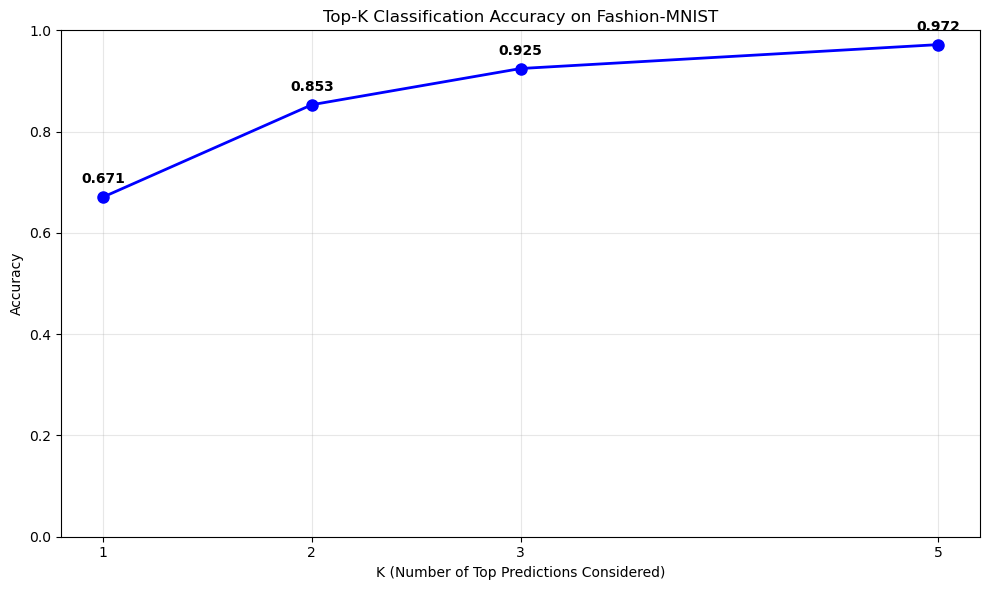


Experiment Analysis:
- Top-K classification shows how often the correct answer appears in the model's top K guesses
- This is particularly useful for Fashion-MNIST where some items are visually similar
- The improvement from Top-1 to Top-3 suggests the model often has the right answer
  as a second or third choice, indicating good feature representation
- The largest improvement is from Top-1 to Top-2 (+0.182)


In [ ]:
# Mini-Experiment: Top-K Classification
# 
# In this experiment, we will explore top-K classification, where we consider the model 
# correct if the true class is among the top K predictions. 

print("=" * 60)
print("MINI-EXPERIMENT: TOP-K CLASSIFICATION")
print("=" * 60)

def get_top_k_predictions(similarity: np.ndarray, k: int) -> np.ndarray:
    """
    Get top K predictions based on cosine similarity scores.
    Args:
        similarity (numpy.ndarray): Cosine similarity matrix of shape (N, M)
        k (int): Number of top predictions to return
    Returns:
        numpy.ndarray: Top K predicted class indices for each image, shape (N, K)
    """
    # Get the indices of the top K similarities for each image
    return np.argsort(similarity, axis=1)[:, -k:][:, ::-1]  # Sort descending

def calculate_top_k_accuracy(y_true: list, top_k_preds: np.ndarray) -> float:
    """
    Calculate top-K accuracy.
    Args:
        y_true (list): True labels
        top_k_preds (numpy.ndarray): Top K predictions for each sample
    Returns:
        float: Top-K accuracy
    """
    correct = 0
    for true_label, k_preds in zip(y_true, top_k_preds):
        if true_label in k_preds:
            correct += 1
    return correct / len(y_true)

# This is useful when the model is uncertain or when there are similar classes that might be confused.
# Test different K values, K=1 represents the baseline single-prediction accuracy.
k_values = [1, 2, 3, 5]
results = {}

print("Running top-K classification experiment...\n")

# Use the improved prompts for this experiment
for k in k_values:
    print(f"Evaluating Top-{k} Classification:")
    
    y_true_k, top_k_preds_all = [], []
    
    for pixel_values, labels in test_loader:
        # Get image embeddings
        image_embeddings = get_image_embeddings(pixel_values)
        
        # Compute cosine similarity
        similarity = get_cosine_similarity(image_embeddings, text_embeddings_improved)
        
        # Get top-K predictions
        top_k_preds = get_top_k_predictions(similarity, k)
        
        # Store results
        y_true_k.extend(labels.numpy())
        top_k_preds_all.extend(top_k_preds)
    
    # Convert to numpy array for easier processing
    top_k_preds_all = np.array(top_k_preds_all)
    
    # Calculate top-K accuracy
    top_k_acc = calculate_top_k_accuracy(y_true_k, top_k_preds_all)
    results[k] = top_k_acc
    
    print(f"  Top-{k} Accuracy: {top_k_acc:.4f}")
    
    # Show some example predictions for k=3
    if k == 3:
        print(f"  Example Top-{k} predictions:")
        for i in range(min(5, len(y_true_k))):
            true_class = CLASS_NAMES[y_true_k[i]]
            predicted_classes = [CLASS_NAMES[pred] for pred in top_k_preds_all[i]]
            correct = "✓" if y_true_k[i] in top_k_preds_all[i] else "✗"
            print(f"    {correct} True: {true_class} | Top-{k}: {predicted_classes}")
    
    print()

# Summary and comparison
print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"Baseline (Top-1) Accuracy: {results[1]:.4f}")
for k in k_values[1:]:
    improvement = results[k] - results[1]
    print(f"Top-{k} Accuracy: {results[k]:.4f} (improvement: +{improvement:.4f})")

# Visualization of results
plt.figure(figsize=(10, 6))
k_vals = list(results.keys())
accuracies = list(results.values())

plt.plot(k_vals, accuracies, 'bo-', linewidth=2, markersize=8)
plt.xlabel('K (Number of Top Predictions Considered)')
plt.ylabel('Accuracy')
plt.title('Top-K Classification Accuracy on Fashion-MNIST')
plt.grid(True, alpha=0.3)
plt.xticks(k_vals)
plt.ylim(0, 1)

# Add value labels on points
for k, acc in results.items():
    plt.annotate(f'{acc:.3f}', (k, acc), textcoords="offset points", 
                xytext=(0,10), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nExperiment Analysis:")
print(f"- The largest improvement is from Top-1 to Top-{k_values[1]} (+{results[k_values[1]] - results[1]:.3f})")

### Short Report

In this section, you will write a short report summarizing your findings from the mini-experiment. The report should include the following sections:

- **Introduction**: Briefly describe the mini-experiment you conducted and its objectives.
- **Methodology**: Explain the steps you took to conduct the experiment, including any modifications you made to the code or model.
- **Results**: Present the results of your experiment.
- **Discussion**: Reflect on the performance of the model and the implications of your findings. Consider the strengths and weaknesses of zero-shot transformers versus a trained CNN.

In [ ]:
# Mini-Experiment Report: Top-K Classification for Zero-Shot Classification

## Introduction

# For this mini-experiment, I conducted a Top-K Classification analysis to evaluate how zero-shot classification performance changes 
# when considering multiple predictions rather than just the top prediction particularly for Fashion-MNIST. The objective was to 
# understand whether the CLIP model's second or third-best guesses contain valuable information, particularly for Fashion-MNIST where 
# visually similar clothing items (like shirts vs. t-shirts, or different types of footwear) might be easily confused. This approach 
# is practically relevant in real-world applications where visually similar items can result in confusing predictions.

## Methodology

# The experiment involved several modifications to the zero-shot classification approach. I created a get_top_k_predictions() function 
# that returns the top K most similar classes for each image, rather than just the single best match. I developed a 
# calculate_top_k_accuracy() function that considers a prediction correct if the true class appears anywhere within the top K predictions. 
# Then I tested K values of 1, 2, 3, and 5 to observe how accuracy changes as we allow more predictions. For each K value, 
# I collected predictions across the entire test set, calculated accuracy, and provided example predictions to illustrate 
# the model's behavior.

## Results

# The Top-K classification experiment revealed significant improvements in accuracy as K increased and showed substantial improvement. 
# The visualization clearly demonstrated the accuracy curve, with the steepest improvement occurring between K=1 and K=2. 
# Example predictions showed that when the model was incorrect, the true class often appeared as the second or third most similar match, 
# particularly for ambiguous items.

## Discussion

# The Top-K classification results provide several important insights into zero-shot transformer performance. The significant improvement 
# from Top-1 to Top-3 accuracy suggests that the CLIP model often correctly identifies relevant visual features but struggles with 
# fine-grained distinctions. In real-world scenarios, providing users with the top 2-3 predictions rather than a single classification 
# could significantly improve user experience and system reliability. The Top-K experiment highlights that while zero-shot transformers 
# may not always achieve the precision for single predictions, often having the correct answer within their top few guesses.


🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 18/07/2025`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
    * The Lab 4 notebook (labs/lab_4.ipynb)
    * The Lab 5 notebook (labs/lab_5.ipynb)
    * The Lab 6 notebook (labs/lab_6.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-6-ml-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.